In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import yfinance as yf

In [3]:
start_date = '2010-12-01'
end_date = '2025-12-31'
dat = yf.download('JPM', start = start_date, end = end_date, interval = '1d')

[*********************100%***********************]  1 of 1 completed


In [4]:
dat

Price,Close,High,Low,Open,Volume
Ticker,JPM,JPM,JPM,JPM,JPM
Date,,,,,
2010-12-01,25.401932,25.428564,25.069010,25.268763,33157200
2010-12-02,26.174314,26.220923,25.521788,25.588371,41526000
2010-12-03,26.374062,26.414011,25.768144,26.014505,30070200
2010-12-06,26.567163,26.667038,26.167656,26.287508,25364500
2010-12-07,26.134359,26.940029,26.127702,26.866786,40908200
...,...,...,...,...,...
2025-12-23,324.466400,326.308099,321.639157,322.156811,6668300
2025-12-24,327.691864,328.508159,324.038331,324.774998,4289300


In [5]:
dat['log-p'] = np.log(dat['Close','JPM'])
dat['r'] = dat['Close'] / dat['Close'].shift(1)
dat['log-r'] = np.log(dat['r'])
dat = dat.dropna()

In [6]:
dat['log-r']

Date
2010-12-02    0.029953
2010-12-03    0.007602
2010-12-06    0.007295
2010-12-07   -0.016425
2010-12-08    0.025407
                ...   
2025-12-23    0.008752
2025-12-24    0.009892
2025-12-26   -0.003835
2025-12-29   -0.012768
2025-12-30   -0.001020
Name: log-r, Length: 3792, dtype: float64

In [7]:
dat['log-p']

Date
2010-12-02    3.264779
2010-12-03    3.272381
2010-12-06    3.279676
2010-12-07    3.263251
2010-12-08    3.288658
                ...   
2025-12-23    5.782182
2025-12-24    5.792074
2025-12-26    5.788239
2025-12-29    5.775471
2025-12-30    5.774451
Name: log-p, Length: 3792, dtype: float64

In [8]:
df_train = dat[:'2023-12-31'] 
df_test = dat['2024-01-01':]
dat_log_r = dat['log-r']
dat_log_p = dat['log-p']

Text(0, 0.5, 'log return')

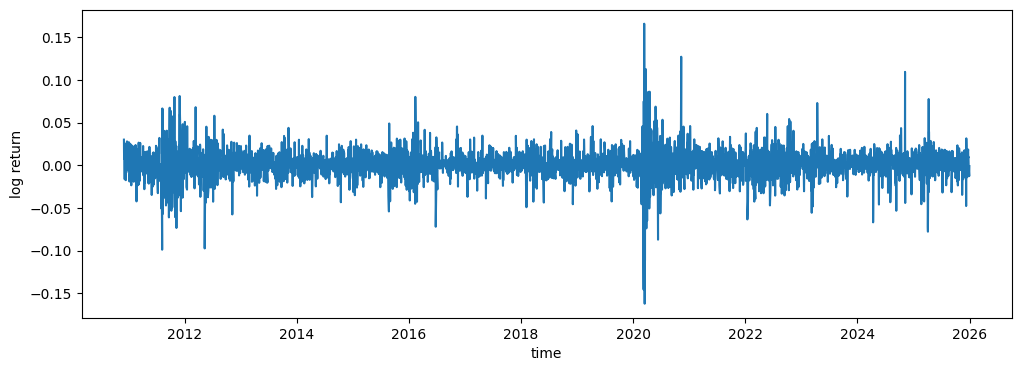

In [9]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(dat_log_r)
ax.set_xlabel('time')
ax.set_ylabel('log return')

In [10]:
from statsmodels.tsa.stattools import adfuller # Augmented Dicky-Fuller test is applied as a statistical test of stationarity

In [11]:
adf_log_r = adfuller(dat_log_r)
adf_log_r[1]  # the p-value

np.float64(1.0359952281091172e-26)

The p-value is far smaller than 0.05 and indicates nonstationarity for the log return rate.

Sample autocorrelations and ACF plot

In [12]:
from statsmodels.tsa.stattools import acf

In [13]:
acf(dat_log_r, nlags=10)

array([ 1.00000000e+00, -8.69210592e-02,  6.98842348e-02, -3.56308398e-02,
       -4.14785327e-02,  2.39702749e-02, -4.89265013e-02,  7.28076951e-02,
       -3.07115583e-02,  3.27327795e-02, -4.80340042e-04])

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

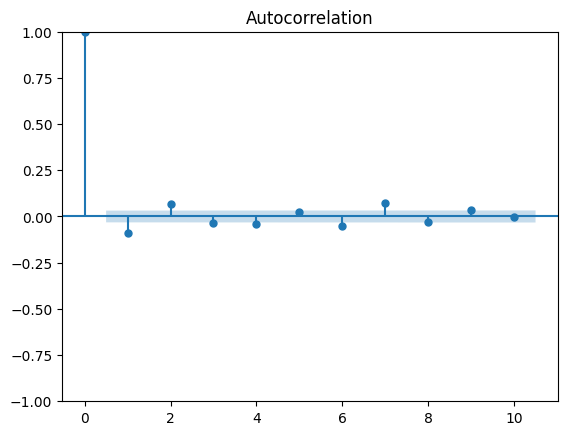

In [15]:
plot_acf(dat_log_r, lags=10);

The sample autocorrelations of most of lags exceed the region. They are evidence against H0.

LB Test

In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox

In [17]:
LB_log_r = acorr_ljungbox(dat_log_r, lags=[1,2,3,4,5,6,7,8,9,10])
LB_log_r

,lb_stat,lb_pvalue
1,28.672258,8.572302e-08
2,47.211197,5.600398e-11
3,52.031709,2.948836e-11
4,58.566060,5.804183e-12
5,60.748872,8.510235e-12
6,69.845352,4.398639e-13
7,89.994391,1.240526e-16
8,93.580456,8.703746e-17
9,97.655151,4.685257e-17
10,97.656029,1.603329e-16


Q(1) ARMA Fitting

In [18]:
train_logr = df_train['log-r']
test_logr = df_test['log-r']
train_logp = df_train['log-p']
test_logp = df_test['log-p']

In [19]:
train_logr

Date
2010-12-02    0.029953
2010-12-03    0.007602
2010-12-06    0.007295
2010-12-07   -0.016425
2010-12-08    0.025407
                ...   
2023-12-22   -0.000597
2023-12-26    0.005896
2023-12-27    0.005980
2023-12-28    0.005299
2023-12-29   -0.001175
Name: log-r, Length: 3291, dtype: float64

In [20]:
test_logr

Date
2024-01-02    0.011573
2024-01-03   -0.004368
2024-01-04    0.006614
2024-01-05    0.005005
2024-01-08   -0.001452
                ...   
2025-12-23    0.008752
2025-12-24    0.009892
2025-12-26   -0.003835
2025-12-29   -0.012768
2025-12-30   -0.001020
Name: log-r, Length: 501, dtype: float64

In [21]:
train_logp

Date
2010-12-02    3.264779
2010-12-03    3.272381
2010-12-06    3.279676
2010-12-07    3.263251
2010-12-08    3.288658
                ...   
2023-12-22    5.071339
2023-12-26    5.077235
2023-12-27    5.083215
2023-12-28    5.088514
2023-12-29    5.087339
Name: log-p, Length: 3291, dtype: float64

In [22]:
test_logp

Date
2024-01-02    5.098912
2024-01-03    5.094544
2024-01-04    5.101158
2024-01-05    5.106163
2024-01-08    5.104711
                ...   
2025-12-23    5.782182
2025-12-24    5.792074
2025-12-26    5.788239
2025-12-29    5.775471
2025-12-30    5.774451
Name: log-p, Length: 501, dtype: float64

In [23]:
from statsmodels.tsa.arima.model import ARIMA

In [24]:
model = ARIMA(train_logr, order=(1,0,1), trend = 'c').fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                  log-r   No. Observations:                 3291
Model:                 ARIMA(1, 0, 1)   Log Likelihood                8659.540
Date:                Sun, 22 Mar 2026   AIC                         -17311.081
Time:                        15:35:53   BIC                         -17286.685
Sample:                             0   HQIC                        -17302.347
                               - 3291                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.927      0.054   -9.61e-06       0.001
ar.L1         -0.6537      0.039    -16.732      0.000      -0.730      -0.577
ma.L1          0.5659      0.041     13.682      0.0

C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [25]:
model.params

const     0.000559
ar.L1    -0.653716
ma.L1     0.565919
sigma2    0.000303
dtype: float64

In [26]:
model.resid

Date
2010-12-02    0.029394
2010-12-03    0.009845
2010-12-06    0.005792
2010-12-07   -0.015854
2010-12-08    0.022713
                ...   
2023-12-22    0.000123
2023-12-26    0.004512
2023-12-27    0.006357
2023-12-28    0.004686
2023-12-29   -0.001288
Length: 3291, dtype: float64

In [27]:
acorr_ljungbox(model.resid, lags=[10], model_df=1)

,lb_stat,lb_pvalue
10,46.155017,5.635922e-07


The LB test shows that the residuals in the AR(1) model do not behave like white noises, and hence AR(1) does not model the data well.

Tuning the order of ARMA

Try several combinations of ar and ma orders and find the best ones by BIC.

In [28]:
best_bic = np.inf  # positive infinity
results = []
for p in range(1,7):
    for q in range(1,7):
        model = ARIMA(train_logr, order=(p,0,q), trend='c').fit()
        if model.bic < best_bic:
            model_best_bic = model
            best_bic = model.bic
            results.append((p,q))

C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be

In [29]:
print(model_best_bic.summary())

                               SARIMAX Results                                
Dep. Variable:                  log-r   No. Observations:                 3291
Model:                 ARIMA(1, 0, 2)   Log Likelihood                8665.576
Date:                Sun, 22 Mar 2026   AIC                         -17321.151
Time:                        15:37:13   BIC                         -17290.657
Sample:                             0   HQIC                        -17310.234
                               - 3291                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.865      0.062   -2.85e-05       0.001
ar.L1         -0.2878      0.111     -2.584      0.010      -0.506      -0.070
ma.L1          0.1998      0.109      1.831      0.0

BIC imposes a stricter penalty on the number of parameters, and hence it selects a more parsimonious model.

In [30]:
print(results[-1])

(1, 2)


ARMA(1,2) with the smallest BIC

In [31]:
acorr_ljungbox(model.resid, lags=[10], model_df=3)

,lb_stat,lb_pvalue
10,3.526105,0.832453


Now LB test indicates p-value is far larger than 0.05, thus we cannot reject H0. Therefore, ARMA(1,2) perfectly fits the log return structure.

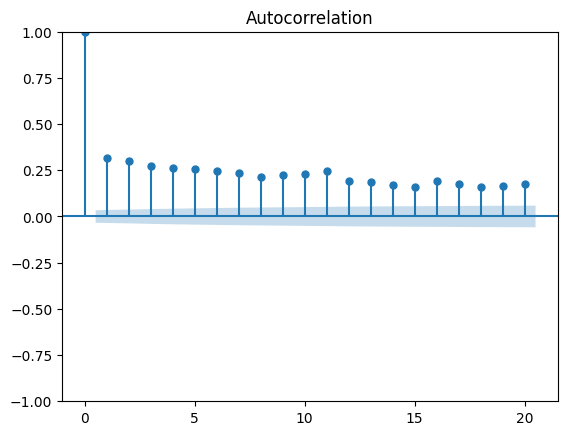

In [32]:
plot_acf(model.resid.abs(), lags=20);

 In the ARMA(1,2) fitting, the noises are assumed to be i.i.d. white noises by default, but the analysis of residuals shows that this is not true. We improve modeling of the noises by GARCH.

Q(2) GARCH forecasting

In [64]:
from arch import arch_model

In [65]:
gm = arch_model(y=train_logr, mean='Constant', vol='GARCH', p=1, q=1, dist='normal', rescale=False).fit()  
print(gm.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 120512581406.49544
Iteration:      2,   Func. Count:     19,   Neg. LLF: 104842696720.65353
Iteration:      3,   Func. Count:     34,   Neg. LLF: 1.289129364952794e+16
Iteration:      4,   Func. Count:     49,   Neg. LLF: 9092884.177511923
Iteration:      5,   Func. Count:     61,   Neg. LLF: 16726849.371364208
Iteration:      6,   Func. Count:     74,   Neg. LLF: 437732256390.9513
Iteration:      7,   Func. Count:     89,   Neg. LLF: 20223682.818287123
Iteration:      8,   Func. Count:    102,   Neg. LLF: 113481605526.8988
Iteration:      9,   Func. Count:    117,   Neg. LLF: 1.7261558722093296e+16
Iteration:     10,   Func. Count:    132,   Neg. LLF: 113102439197.05855
Iteration:     11,   Func. Count:    147,   Neg. LLF: 36160.896171048546
Iteration:     12,   Func. Count:    156,   Neg. LLF: -9186.046099183539
Optimization terminated successfully    (Exit mode 0)
            Current function value: -9186.046098250057
           

Both AIC and BIC show that the garch model is better than the arma(1,2) model with i.i.d. white noises. We further analyze the standardized residuals of the garch model.

In [66]:
resid_std = gm.resid/gm.conditional_volatility

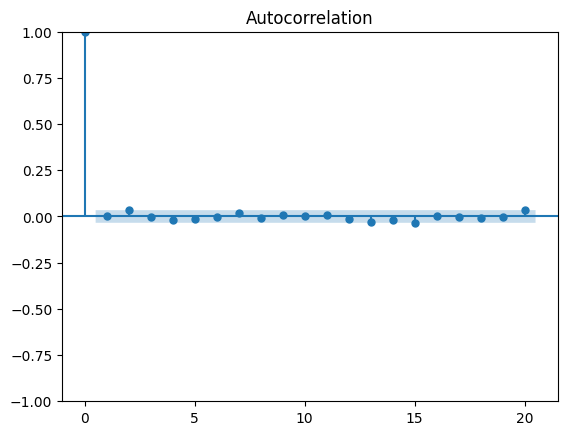

In [67]:
plot_acf(resid_std, lags=20);

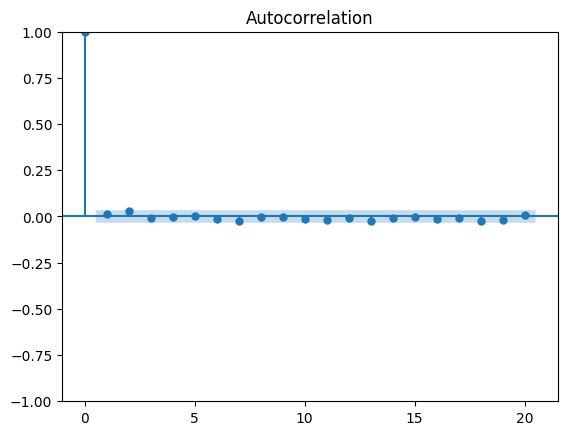

In [68]:
plot_acf(resid_std**2, lags=20);

In [69]:
acorr_ljungbox(resid_std, lags=[10], model_df=0)

,lb_stat,lb_pvalue
10,7.464693,0.680966


Define a rolling forecast function

In [70]:
def rolling_forecast(model, new_obs, horizon):
    forecast = model.forecast(horizon)
    model_updated = model 
    for obs in new_obs:
        model_updated = model_updated.append([obs], refit=False)
        forecast = pd.concat([forecast, model_updated.forecast(horizon)])
    return forecast

In [71]:
test_logr[:-1]

Date
2024-01-02    0.011573
2024-01-03   -0.004368
2024-01-04    0.006614
2024-01-05    0.005005
2024-01-08   -0.001452
                ...   
2025-12-22    0.018367
2025-12-23    0.008752
2025-12-24    0.009892
2025-12-26   -0.003835
2025-12-29   -0.012768
Name: log-r, Length: 500, dtype: float64

(a) Horizon = 1

In [72]:
logr_forecast = rolling_forecast(model, test_logr[:-1], 1)
logr_forecast

C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.


3291   -0.000413
3292    0.000050
3293    0.000550
3294   -0.000166
3295   -0.000081
          ...   
3787   -0.000360
3788    0.001396
3789   -0.001933
3790    0.001994
3791   -0.000827
Length: 501, dtype: float64

In [73]:
anchor = pd.concat([train_logp.iloc[[-1]], test_logp[:-1]])
logp_forecast = anchor.values + logr_forecast.values

In [74]:
from sklearn.metrics import mean_squared_error

In [75]:
RMSE = np.sqrt(mean_squared_error(logp_forecast, test_logp))
RMSE

np.float64(0.015224649183254203)

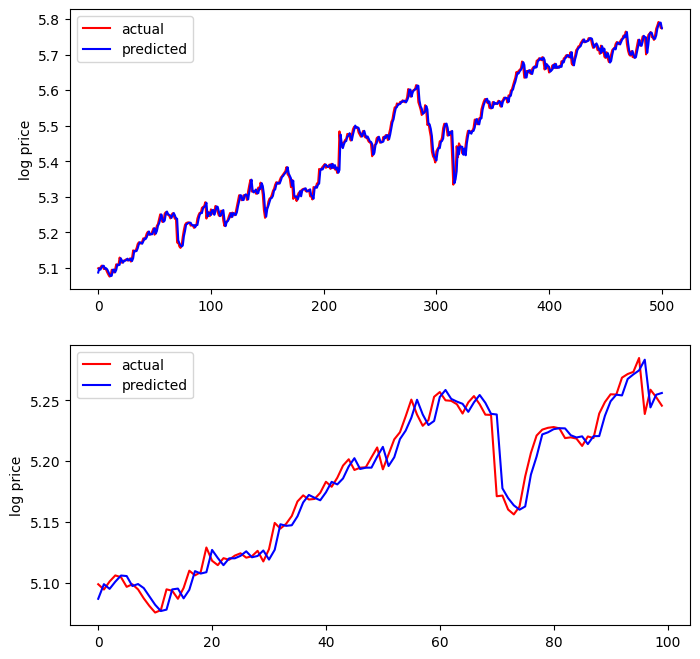

In [76]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 8))
ax[0].plot(test_logp.values.ravel(), c='red', label='actual')  
ax[0].plot(logp_forecast, c='blue', label='predicted')
ax[0].set_ylabel('log price')
ax[0].legend();

ax[1].plot(test_logp.values.ravel()[:100], c='red', label='actual')  
ax[1].plot(logp_forecast[:100], c='blue', label='predicted')
ax[1].set_ylabel('log price')
ax[1].legend();

(b) Horizon = 5

In [77]:
logr_forecast = rolling_forecast(model, test_logr[:-1], 5)
logr_forecast

C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.


3291   -0.000413
3292    0.001094
3293   -0.000518
3294    0.001042
3295    0.000396
          ...   
3791   -0.000827
3792    0.000039
3793    0.000984
3794    0.001021
3795    0.001661
Name: predicted_mean, Length: 2505, dtype: float64

In [78]:
anchor = pd.concat([train_logp.iloc[[-1]], test_logp[:-1]])
for k in range(1, 6):
    logr_k = logr_forecast.iloc[k-1::5].values 
    logp_forecast_k = anchor.values + logr_k
    rmse_k = np.sqrt(mean_squared_error(logp_forecast_k[:501-(k-1)], test_logp.values[k-1:]))

In [79]:
rmse_k

np.float64(0.033623877158741745)

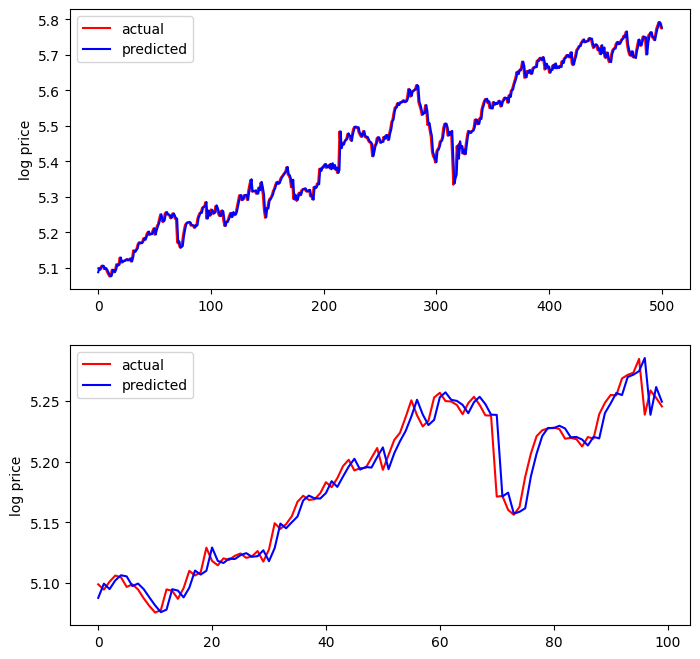

In [80]:
logp_forecast = anchor.values + logr_forecast.iloc[4::5].values
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 8))
ax[0].plot(test_logp.values.ravel(), c='red', label='actual')  
ax[0].plot(logp_forecast, c='blue', label='predicted')
ax[0].set_ylabel('log price')
ax[0].legend();

ax[1].plot(test_logp.values.ravel()[:100], c='red', label='actual')  
ax[1].plot(logp_forecast[:100], c='blue', label='predicted')
ax[1].set_ylabel('log price')
ax[1].legend();

(c) Horizon = 20

In [81]:
logr_forecast = rolling_forecast(model, test_logr[:-1], 20)
logr_forecast

C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.


3291   -0.000413
3292    0.001094
3293   -0.000518
3294    0.001042
3295    0.000396
          ...   
3806    0.000589
3807    0.000643
3808    0.000430
3809    0.000642
3810    0.000373
Name: predicted_mean, Length: 10020, dtype: float64

In [82]:
anchor = pd.concat([train_logp.iloc[[-1]], test_logp[:-1]])
for k in range(1, 21):
    logr_k = logr_forecast.iloc[k-1::20].values 
    logp_forecast_k = anchor.values + logr_k
    rmse_k = np.sqrt(mean_squared_error(logp_forecast_k[:501-(k-1)], test_logp.values[k-1:]))

In [83]:
rmse_k

np.float64(0.06399406253021932)

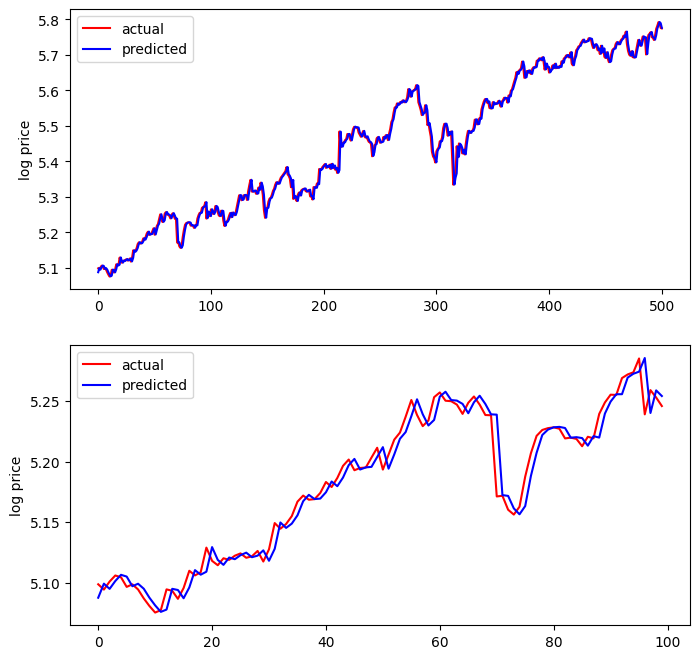

In [84]:
logp_forecast = anchor.values + logr_forecast.iloc[19::20].values
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 8))
ax[0].plot(test_logp.values.ravel(), c='red', label='actual')  
ax[0].plot(logp_forecast, c='blue', label='predicted')
ax[0].set_ylabel('log price')
ax[0].legend();

ax[1].plot(test_logp.values.ravel()[:100], c='red', label='actual')  
ax[1].plot(logp_forecast[:100], c='blue', label='predicted')
ax[1].set_ylabel('log price')
ax[1].legend();

So we will find that RMSE = 0.015, 0.033, 0.063 when h = 1, 5, 20. RMSE increases from 0.015 to 0.063. Prediction accuracy decreases in longer horizons.